In [ ]:
!pip install colorcet

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import umap
from matplotlib.colors import hsv_to_rgb

import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
from gensim.models import Word2Vec
import colorcet as cc

from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize

In [159]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist


def alignment(coords, labels):
    red = coords[np.array(labels)==1]
    blue = coords[np.array(labels)==0]
    D = cdist(red, blue)
    row_ind, col_ind = linear_sum_assignment(D)

    matching_dist = D[row_ind, col_ind].mean()
    print("Mean optimal matching distance:", matching_dist)
    return matching_dist


Mean optimal matching distance: 0.2592028101935927


0.2592028101935927

In [18]:
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts

def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
    return unit_concepts, set(raw_concepts)
 

## Dense 1 Color Sparse 1 Color -- Word2Vec

In [93]:
with open('data/analysis/snli_1.0_dev.tok', 'r') as f:
    samples = f.readlines()
sentences = []
for sentence in samples:
    sentences.append(sentence.split())

In [220]:
w2v = Word2Vec(sentences, vector_size=128, window=5, epochs=10, workers=4, min_count=1)
embeddings=[]
used_words=[]

rels0=[{'old', 'older'}, {'horses', 'horse'}, {'motorcycle', 'bicycle', 'bike'}, {'player', 'football', 'basketball', 'tennis', 'game', 'win', 'baseball', 'racket', 'soccer', 'play', 'frisbee', 'volleyball', 'players', 'hockey', 'team'}, {'nap', 'asleep', 'bed', 'sleep', 'couch'}, {'girl', 'boys', 'boy', 'girls', 'kids', 'family', 'children', 'young', 'child'}, {'vbz', 'vbn', 'vbd', 'vbp', 'nn', 'POS', 'nns', 'vb', 'jj', 'nnp', 'vbg'}, {'nobody', 'something'}, {'black', 'gray', 'blue', 'purple', 'pink', 'white', 'red', 'yellow', 'orange', 'brown', 'green'}, {'catch', 'ball'}, {'suit', 'jeans'}, {'working', 'looking', 'running'}, {'bar', 'coffee'}, {'dog', 'dogs', 'animal', 'cat'}, {'dress', 'wearing'}, {'new', 'another'}, {'wave', 'smiling'}, {'car', 'driving', 'park'}, {'there', 'one', 'as', 'each', 'is', 'alone', 'not', 'because', 'no'}, {'through', 'around', 'into', 'down', 'out', 'on', 'behind'}, {'race', 'racing'}, {'wall', 'brick'}, {'riding', 'ride'}, {'floor', 'room', 'kitchen'}, {'birthday', 'bride', 'party'}, {'woman', 'lady', 'man', 'female', 'men', 'women'}, {'set', 'couple', 'other', 'several', 'lot', 'all', 'about', 'some'}, {'desk', 'table'}, {'skateboarder', 'snowboarder', 'skateboard'}, {'edge', 'in', 'outside', 'front'}, {'sit', 'seated', 'bench'}, {'his', 'she', 'he', 'her'}, {'river', 'lake'}, {'and', 'with'}, {'next', 'while', 'after'}, {'dinner', 'lunch'}, {'sand', 'dirt', 'rocks'}, {'band', 'track', 'music'}, {'acoustic', 'guitar'}, {'crowd', 'audience'}, {'train', 'bus'}, {'human', 'humans'}, {'son', 'mother'}, {',', '.'}, {'three', 'two'}, {'street', 'city'}]
rels68=[{'rain', 'snowy', 'ice', 'snow'}, {'dogs', 'cat', 'dog', 'animal', 'cats'}, {'orange', 'white', 'pink', 'black', 'yellow', 'green', 'brown', 'purple', 'dark', 'blue', 'red'}, {'building', 'project'}, {'table', 'chair', 'desk'}, {'looking', 'working', 'trick', 'running'}, {'skateboarding', 'skateboard', 'skateboarder', 'snowboarding', 'snowboarder'}, {'vbn', 'jj', 'POS', 'nnp', 'nns', 'vbz', 'vbd', 'nn', 'vbp', 'vb', 'vbg'}, {'racket', 'tennis', 'soccer', 'basketball', 'football', 'volleyball', 'frisbee', 'baseball', 'hockey'}, {'phone', 'cellphone'}, {'while', 'after', 'during', 'next'}, {'player', 'play', 'game'}, {'naked', 'asian'}, {'suit', 'jeans'}, {'wife', 'son', 'sisters'}, {'humans', 'human'}, {'bus', 'train'}, {'up', 'into', 'on', 'down'}, {'dinner', 'lunch'}, {'haired', 'blond'}, {'street', 'city'}, {'wearing', 'dress'}, {'road', 'mountain'}, {'classroom', 'school'}, {'nap', 'sleep', 'bed', 'couch', 'asleep'}, {'painting', 'drawing'}, {'horses', 'horse'}, {'riding', 'ride'}, {'older', 'old'}, {'pool', 'outdoors', 'indoor'}, {'is', 'one', 'as', '.', 'there', 'someone', 'no', 'something', 'that', 'alone', 'because', 'nobody', 'just', 'not', ','}, {'children', 'boys', 'young', 'girl', 'kids', 'boy', 'girls'}, {'him', 'his', 'her', 'he'}, {'lady', 'men', 'man', 'female', 'woman', 'women'}, {'lake', 'river'}, {'bike', 'bicycle', 'motorcycle'}, {'dirt', 'sand', 'mud'}, {'with', 'and'}, {'park', 'driving', 'car'}, {'all', 'some', 'other'}, {'room', 'kitchen'}
        , {'outside', 'in'}, {'cafe', 'restaurant'}, {'racing', 'race'}, {'birthday', 'party'}, {'band', 'music', 'track'}, {'woods', 'tree'}]

rels77=[{'dogs', 'animal', 'dog', 'cats', 'cat'}, {'vb', 'vbz', 'nnp', 'nn', 'vbg', 'POS', 'jj', 'vbn', 'vbd', 'nns', 'vbp'}, {'humans', 'human'}, {'with', 'and'}, {'frisbee', 'play', 'soccer', 'team', 'basketball', 'hockey', 'volleyball', 'tennis', 'baseball', 'football', 'game', 'racket', 'player'}, {'snowy', 'snow', 'ice'}, {'classroom', 'school'}, {'cellphone', 'phone'}, {'his', 'her', 'he'}, {'truck', 'park', 'driving', 'car'}, {'river', 'lake'}, {'rocky', 'dirt', 'rocks', 'sand', 'mud'}, {'train', 'bus'}, {'asleep', 'sleep', 'couch', 'nap', 'bed'}, {'music', 'track', 'band'}, {'skateboard', 'snowboarding', 'snowboarder', 'skateboarder'}, {'horse', 'horses'}, {'as', 'one', 'is'}, {'trick', 'running', 'working', 'looking'}, {'orange', 'pink', 'white', 'red', 'dark', 'purple', 'yellow', 'brown', 'blue', 'black', 'green'}, {'child', 'girl', 'boy', 'boys', 'kids', 'young', 'girls', 'children'}, {'two', 'four', 'couple', 'three'}, {'wear', 'dress', 'wearing'}, {'shirtless', 'naked', 'asian'}, {'dinner', 'lunch'}, {'for', 'preparing'}, {'woods', 'tree'}, {'women', 'woman', 'lady', 'men', 'man', 'female'}, {'nobody', 'something'}, {'kitchen', 'floor', 'room'}, {'home', 'house'}, {'new', 'another'}, {'bike', 'motorcycle', 'bicycle'}, {'there', 'no', 'not', 'alone'}, {'through', 'on', 'down', 'behind', 'back', 'into', 'up'}, {'in', 'outside', 'front'}, {'bar', 'coffee'}, {'race', 'racing'}, {'sweater', 'hat'}, {'jeans', 'suit'}, {'city', 'street'}, {'birthday', 'party'}, {'while', 'next', 'after'}, {'wave', 'smiling'}, {'ride', 'riding'}, {',', '.'}, {'table', 'desk'}, {'old', 'older'}]

rels=[rels0,rels68]

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


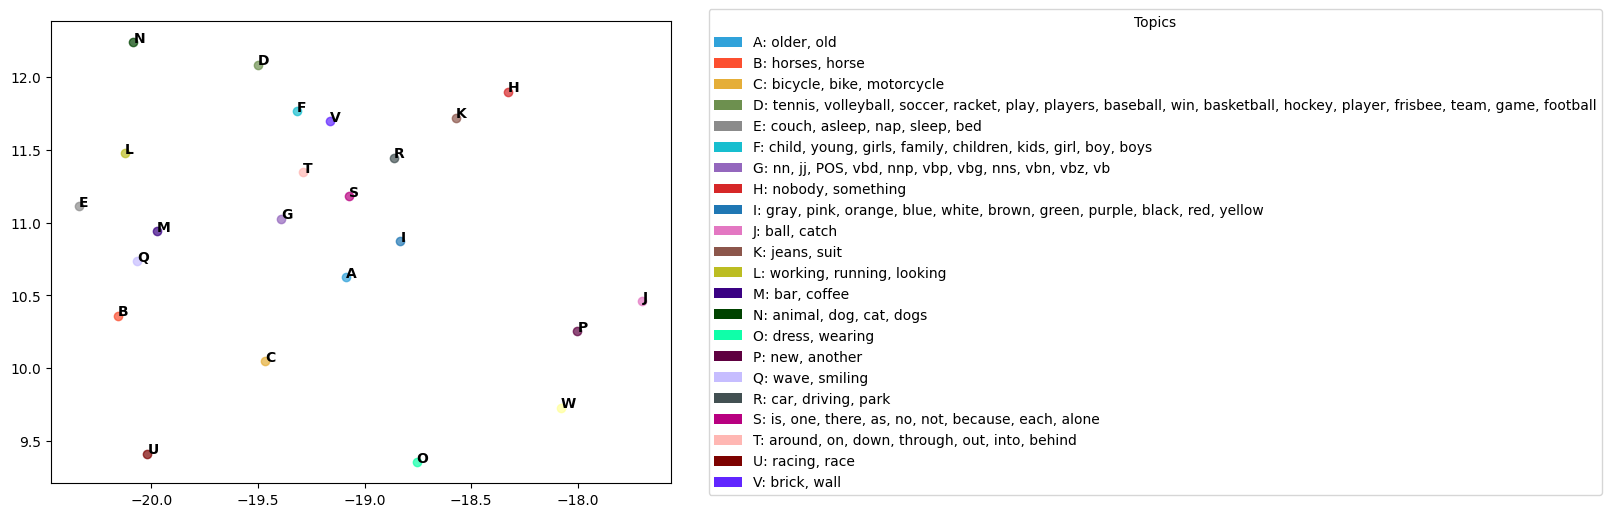

Mean optimal matching distance: 0.5574207062050512


0.5574207062050512

In [245]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import umap

# pick the first clustering


w2v = Word2Vec([' '.join(r) for r in rel for rel in rels], vector_size=128, window=5, epochs=10, workers=4, min_count=1)
group = {}
groupings=[]
coords_list=[]
embeddings = []
for index,rel in enumerate(rels):

    # ---- collect embeddings ----
    
    rel = sorted(rel)
    offset = len(group)
   
    for i, cluster in enumerate(rel):
        if i > subset: break
        embedding = torch.zeros((128,))
        for word in cluster:
            
            word_lower = word.lower()
            if word_lower not in w2v.wv:
                continue
            
            embedding += w2v.wv[word_lower]
        embeddings.append(np.array(embedding/len(cluster)))
        group[i+offset] = index
        groupings.append(cluster)

    # ---- word -> cluster mapping ----
    word_to_cluster = {}
    for cid, cluster in enumerate(rel):
        word_to_cluster[cid] = cid

labels = [group[i] for i in group]

# ---- UMAP projection ----
embeddings = np.array(embeddings)

reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)

coords = reducer.fit_transform(embeddings)  # supervised


    # ---- colors ----



num_abstractions = len(embeddings) #len(rels[0]) + len(rels[1])
colors_list = cc.glasbey_hv[:num_abstractions]


fig = plt.figure(figsize=(8, 6))

import string

point_labels = list(string.ascii_uppercase)

for i, ((x, y), l) in enumerate(zip(coords, labels)):
    if i > subset:
        break

    plt.scatter(x, y, alpha=0.7, color=colors_list[i])
    plt.text(x, y, point_labels[i], fontsize=10, weight='bold')


legend_elements = [
    Patch(
        facecolor=colors_list[i],
        label=f"{point_labels[i]}: {', '.join(groupings[i])}"
    )
    for i in range(min(subset, len(groupings)))
]

plt.legend(
    handles=legend_elements,
    title="Topics",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5)
)
plt.show()
alignment(coords, labels)



#build datset
dataset = [' '.join(sentence) for sentence in sentences]
#train doc2vec
tagged_data = [TaggedDocument(words=word_tokenize(doc.lower()),
                              tags=[str(i)]) for i,
               doc in enumerate(dataset)]
model = Doc2Vec(vector_size=20, min_count=0, epochs=50)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)
## Dense 1 color, Sparse 1 color -- Doc2Vec

In [200]:
#build datset
dataset = [' '.join(r) for r in rel for rel in rels]
#train doc2vec
tagged_data = [TaggedDocument(words=word_tokenize(doc.lower()),
                              tags=[str(i)]) for i,
               doc in enumerate(dataset)]
model = Doc2Vec(vector_size=20, min_count=0, epochs=50)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)


+==========================
+==========================


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


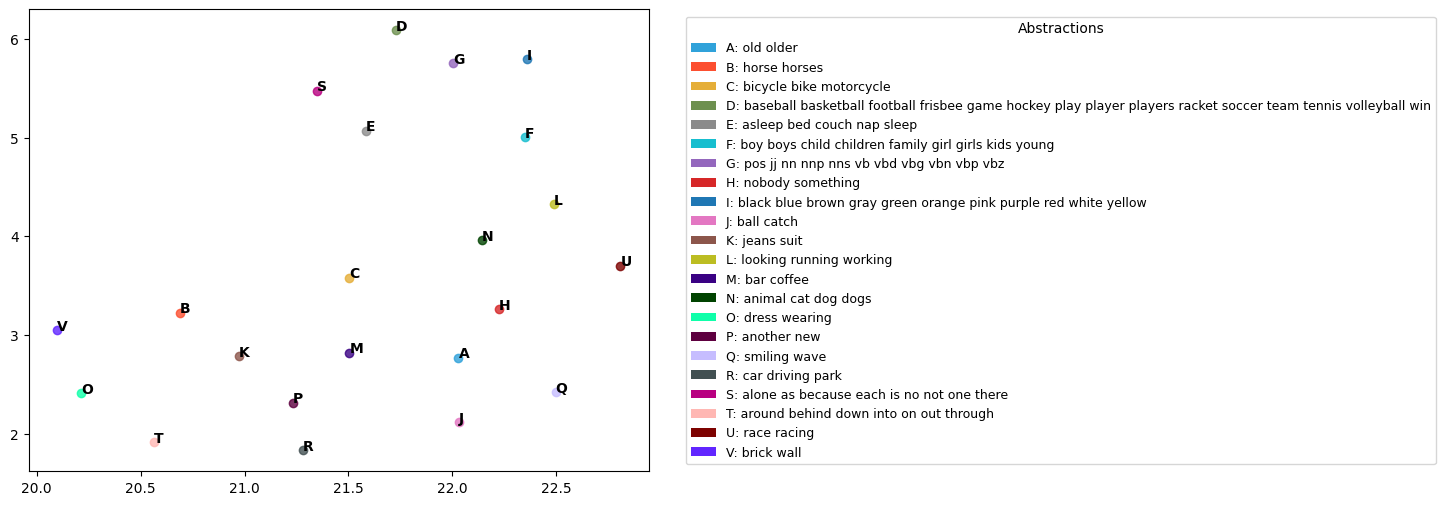

22 22
Mean optimal matching distance: nan


/tmp/ipykernel_10580/1143190265.py:11: RuntimeWarning: Mean of empty slice.
  matching_dist = D[row_ind, col_ind].mean()
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


nan

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import umap
coords_list=[]
num_abstractions_list=[]
subset=22
embeddings= []
groupings=[]
group = {}
import string

point_labels = list(string.ascii_uppercase)

for index, rel in enumerate(rels):
    offset = len(group)
    
    print("+==========================")
    dataset = [' '.join(sorted(r)) for r in rel]
    embedding = [model.infer_vector(word_tokenize(doc.lower())) for doc in dataset]
    groupings.extend([d.lower() for d in dataset])
    
    # pick the first clustering

    used_words = range(len(rel))

    # ---- collect embeddings ----
    for i, abstraction in enumerate(rel):
        group[i+offset]=index
        
    embedding = np.array(embedding)
    embeddings.extend(embedding)
    

embeddings = embeddings[:subset]
labels = [group[w] for w in group]
labels = labels[:subset]

# ---- UMAP projection ----
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
coords = reducer.fit_transform(embeddings)  # unsupervised
coords = coords[:subset]
num_abstractions = subset #len(rel)
num_abstractions_list.append(num_abstractions)
fig = plt.figure(figsize=(8, 6))

num_abstractions = subset #len(rels[0]) + len(rels[1])
colors_list = cc.glasbey_hv[:num_abstractions]
for i, ((x, y), l) in enumerate(zip(coords, labels)):
    if i >= subset:
        break

    plt.scatter(x, y, color=colors_list[i], alpha=0.8)
    plt.text(x, y, point_labels[i], fontsize=10, weight='bold')


legend_elements = [
    Patch(
        facecolor=colors_list[i],
        label=f"{point_labels[i]}: {groupings[i]}"
    )
    for i in range(subset)
]

plt.legend(
    handles=legend_elements,
    title="Abstractions",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9
)

plt.show()  
print(len(coords), len(labels))
alignment(coords, labels)

Mean optimal matching distance: 0.3363059925402374


0.3363059925402374

## Each topic as seperate color

range(0, 47)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


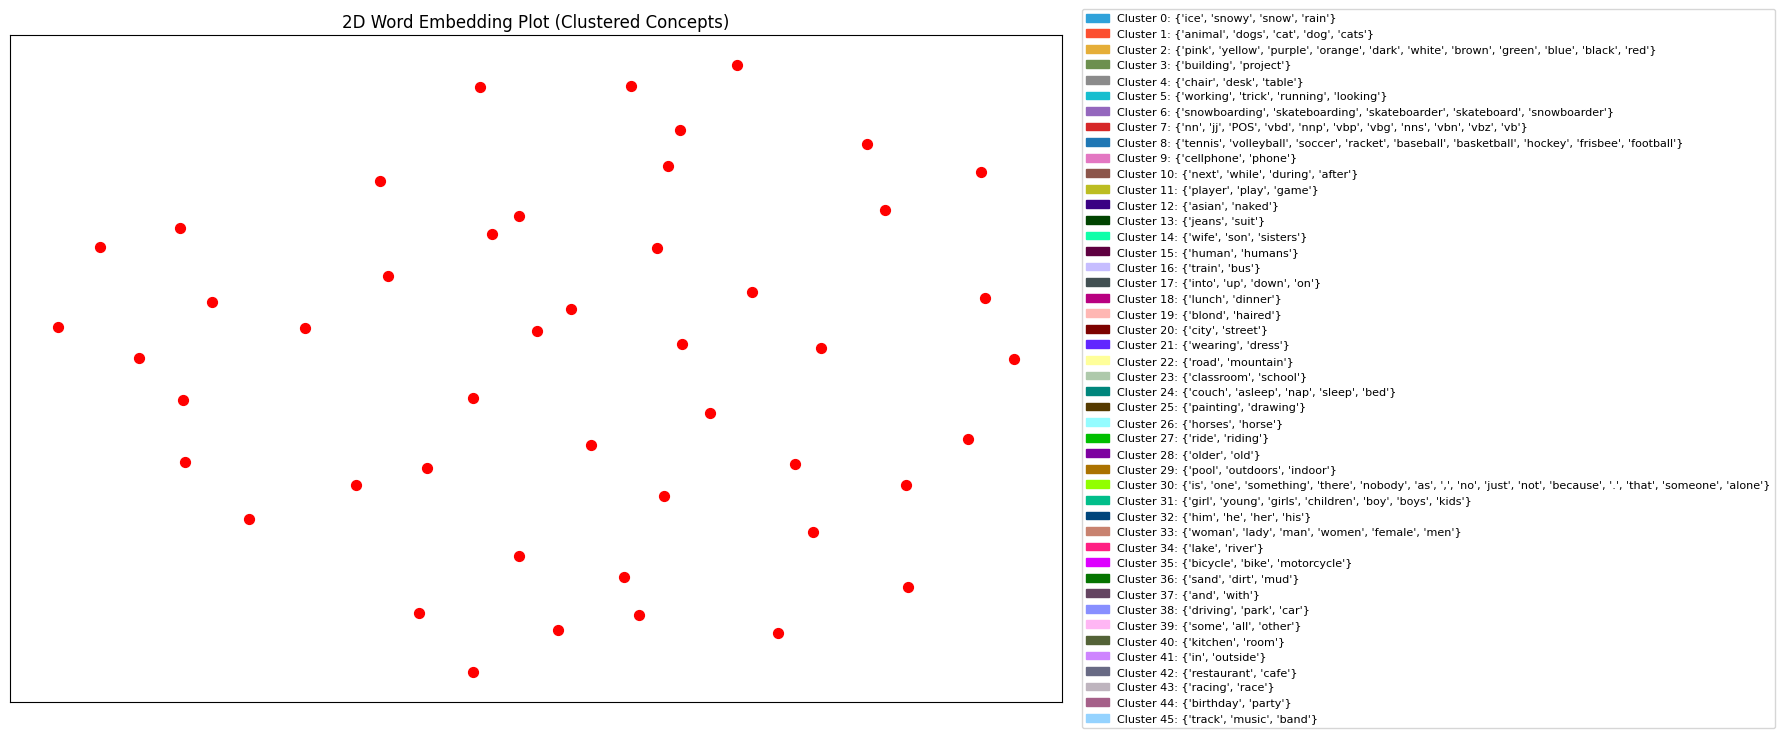

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import umap
rel = rels68
#build datset
dataset = [' '.join(r) for r in rel]
#train doc2vec
tagged_data = [TaggedDocument(words=word_tokenize(doc.lower()),
                              tags=[str(i)]) for i,
               doc in enumerate(dataset)]
model = Doc2Vec(vector_size=20, min_count=0, epochs=50)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)
embeddings = [model.infer_vector(word_tokenize(doc.lower())) for doc in dataset]

# pick the first clustering


used_words = range(len(rel))

# ---- collect embeddings ----
for abstraction in rel:
    for word in abstraction:
        word_lower = word.lower()
        if word_lower not in model.wv.key_to_index:
            continue
        
    #used_words.append(abstraction)
print(used_words)
embeddings = np.array(embeddings)

# ---- word -> cluster mapping ----
word_to_abstraction = {}
for cid, abstraction in enumerate(rel):
    for word in abstraction:
        word_to_abstraction[word.lower()] = cid

labels = [w for w in used_words]

# ---- UMAP projection ----
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
coords = reducer.fit_transform(embeddings, y=labels)  # supervised

# ---- colors ----
num_abstractions = len(rel)
colors_list = cc.glasbey_hv[:num_abstractions]
colors = [colors_list[w] for w in used_words]

# ---- plot figure with 2 subplots ----
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [4, 1]})

# ---- scatter plot ----
ax_scatter = axes[0]
for (x, y), c in zip(coords, colors):
    ax_scatter.scatter(x, y, color=c, s=50)

ax_scatter.set_title("2D Word Embedding Plot (Clustered Concepts)")
ax_scatter.set_xticks([])
ax_scatter.set_yticks([])

# ---- legend ----
ax_legend = axes[1]
legend_elements = [
    Patch(color=colors_list[cid], label=f"Cluster {cid}: {rel[cid]}")
    for cid in range(num_clusters)
]
ax_legend.legend(handles=legend_elements, loc='center', fontsize=8)
ax_legend.axis("off")  # hide axes for legend

plt.tight_layout()
plt.show()
